# Physics-informed recurrent finite-volume solver for DWO

В этом ноутбуке LSTM/ConvLSTM-подобная сеть обучается **без целевых траекторий**. На каждом временном шаге сеть предлагает $h^{n+1}(z)$ и $G_{in}^{n+1}$, после чего:

1. профиль $G^{n+1}(z)$ восстанавливается из дискретного уравнения неразрывности;
2. loss вычисляется по консервативному FV-уравнению энергии;
3. интегральный momentum balance задаёт динамику расхода;
4. FV solver и Excel-траектории используются только для независимой проверки.

Состояние модели: профиль энтальпии, входной расход, интеграл расхода по каналу и hidden/cell state LSTM. Давление сеть не предсказывает.


In [37]:
import sys
import math
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    from iapws import IAPWS97
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Установите зависимости: pip install iapws openpyxl"
    ) from exc

for candidate in (Path.cwd(), Path('/mnt/data')):
    if str(candidate) not in sys.path:
        sys.path.append(str(candidate))

try:
    # Use the original project implementation when available.
    from eos_iapws_spline import EOSGridSpec, IAPWSDensitySpline
except ModuleNotFoundError:
    # Self-contained fixed-pressure fallback. The current model evaluates EOS
    # only at p_ref=25 MPa, so a 1-D cubic spline in enthalpy is sufficient.
    @dataclass(frozen=True)
    class EOSGridSpec:
        p_min: float = 24.5e6
        p_max: float = 25.5e6
        h_min: float = 0.75e6
        h_max: float = 4.20e6
        n_p: int = 64
        n_h: int = 256
        kx: int = 3
        ky: int = 3
        smoothing: float = 0.0


    class IAPWSDensitySpline:
        def __init__(self, spec, h_grid, rho_grid, p_ref=None):
            self.spec = spec
            self.h_grid = np.asarray(h_grid, dtype=np.float64)
            self.rho_grid = np.asarray(rho_grid, dtype=np.float64)
            self.p_ref = float(0.5 * (spec.p_min + spec.p_max) if p_ref is None else p_ref)
            self.spline = CubicSpline(self.h_grid, self.rho_grid, bc_type="natural")

        @classmethod
        def build(cls, spec):
            p_ref = 0.5 * (spec.p_min + spec.p_max)
            h_grid = np.linspace(spec.h_min, spec.h_max, spec.n_h)
            rho_grid = np.array([
                IAPWS97(P=p_ref / 1e6, h=h / 1e3).rho for h in h_grid
            ], dtype=np.float64)
            return cls(spec, h_grid, rho_grid, p_ref=p_ref)

        def save(self, path):
            np.savez(
                path,
                h_grid=self.h_grid,
                rho_grid=self.rho_grid,
                p_ref=self.p_ref,
                p_min=self.spec.p_min,
                p_max=self.spec.p_max,
                h_min=self.spec.h_min,
                h_max=self.spec.h_max,
                n_p=self.spec.n_p,
                n_h=self.spec.n_h,
            )

        @classmethod
        def load(cls, path):
            data = np.load(path)
            required = {"h_grid", "rho_grid"}
            if not required.issubset(data.files):
                raise ValueError("Existing EOS cache has an incompatible format")
            spec = EOSGridSpec(
                p_min=float(data["p_min"]) if "p_min" in data else 24.5e6,
                p_max=float(data["p_max"]) if "p_max" in data else 25.5e6,
                h_min=float(data["h_min"]) if "h_min" in data else float(data["h_grid"][0]),
                h_max=float(data["h_max"]) if "h_max" in data else float(data["h_grid"][-1]),
                n_p=int(data["n_p"]) if "n_p" in data else 1,
                n_h=int(data["n_h"]) if "n_h" in data else len(data["h_grid"]),
            )
            p_ref = float(data["p_ref"]) if "p_ref" in data else 0.5 * (spec.p_min + spec.p_max)
            return cls(spec, data["h_grid"], data["rho_grid"], p_ref=p_ref)

        def eval(self, p_abs, h_abs, clip=True):
            h = np.asarray(h_abs, dtype=np.float64)
            if clip:
                h = np.clip(h, self.h_grid[0], self.h_grid[-1])
            rho = self.spline(h)
            rho_h = self.spline(h, 1)
            rho_p = np.zeros_like(rho)
            return {"rho": rho, "rho_h": rho_h, "rho_p": rho_p}

        def eval_torch(self, p_abs, h_abs, clip=True):
            out = self.eval(
                p_abs.detach().cpu().numpy(),
                h_abs.detach().cpu().numpy(),
                clip=clip,
            )
            rho_value = torch.as_tensor(out["rho"], device=h_abs.device, dtype=h_abs.dtype)
            rho_h = torch.as_tensor(out["rho_h"], device=h_abs.device, dtype=h_abs.dtype)
            rho_p = torch.zeros_like(rho_value)
            rho = rho_value + rho_h * (h_abs - h_abs.detach())
            if p_abs.requires_grad:
                rho = rho + rho_p * (p_abs - p_abs.detach())
            return {"rho": rho, "rho_h": rho_h, "rho_p": rho_p}


In [38]:
@dataclass(frozen=True)
class Forcing:
    time: np.ndarray
    tau: np.ndarray
    power: np.ndarray
    flow_in: np.ndarray
    flow_out: np.ndarray
    ntpc: np.ndarray
    mdot0: float

    @classmethod
    def from_excel(cls, path, t0_ramp=2.0):
        df = pd.read_excel(path)

        cols = ["Time [s]", "Flow-in [kg/s]", "Flow-out [kg/s]", "Power [W]", "NTPC"]
        df = df[cols].apply(pd.to_numeric, errors="coerce").dropna()
        df = df.sort_values("Time [s]")

        pre = df[
            (df["Time [s]"] >= 1.0)
            & (df["Time [s]"] <= 1.8)
            & (df["Power [W]"].abs() < 1e-12)
        ]

        mdot0 = float(pre["Flow-in [kg/s]"].mean())

        df = df[df["Time [s]"] >= t0_ramp].copy()
        time = df["Time [s]"].to_numpy()
        tau = time - t0_ramp

        return cls(
            time=time,
            tau=tau,
            power=df["Power [W]"].to_numpy(),
            flow_in=df["Flow-in [kg/s]"].to_numpy(),
            flow_out=df["Flow-out [kg/s]"].to_numpy(),
            ntpc=df["NTPC"].to_numpy(),
            mdot0=mdot0,
        )

    def power_torch(self, tau):
        x = tau.detach().cpu().numpy().reshape(-1)
        y = np.interp(x, self.tau, self.power)

        return torch.as_tensor(
            y,
            dtype=tau.dtype,
            device=tau.device,
        ).reshape_as(tau)

In [39]:
eos_path = Path("iapws_density_spline_25mpa.npz")

spec = EOSGridSpec(
    p_min=24.5e6,
    p_max=25.5e6,
    h_min=0.75e6,
    h_max=4.20e6,
    n_p=64,
    n_h=256,
    kx=3,
    ky=3,
    smoothing=0.0,
)

if eos_path.exists():
    try:
        eos = IAPWSDensitySpline.load(eos_path)
    except Exception as exc:
        print("EOS cache is incompatible; rebuilding:", exc)
        eos = IAPWSDensitySpline.build(spec)
        eos.save(eos_path)
else:
    eos = IAPWSDensitySpline.build(spec)
    eos.save(eos_path)


In [40]:
@dataclass(frozen=True)
class MuGridSpec:
    p_ref: float = 25.0e6
    h_min: float = 0.75e6
    h_max: float = 4.20e6
    n_h: int = 512


class IAPWSViscositySpline:
    def __init__(self, spec, h_grid, mu_grid):
        self.spec = spec
        self.h_grid = np.asarray(h_grid, dtype=np.float64)
        self.mu_grid = np.asarray(mu_grid, dtype=np.float64)
        self.spline = CubicSpline(self.h_grid, self.mu_grid, bc_type="natural")

    @classmethod
    def build(cls, spec=MuGridSpec()):
        h_grid = np.linspace(spec.h_min, spec.h_max, spec.n_h)
        mu_grid = np.empty_like(h_grid)

        for i, h in enumerate(h_grid):
            mu_grid[i] = IAPWS97(P=spec.p_ref / 1e6, h=h / 1e3).mu

        return cls(spec, h_grid, mu_grid)

    def eval(self, h_abs, clip=True):
        h = np.asarray(h_abs, dtype=np.float64)

        if clip:
            h = np.clip(h, self.h_grid[0], self.h_grid[-1])

        return {
            "mu": self.spline(h),
            "mu_h": self.spline(h, 1),
        }

    def eval_torch(self, h_abs, clip=True):
        out = self.eval(
            h_abs.detach().cpu().numpy(),
            clip=clip,
        )

        mu_value = torch.as_tensor(
            out["mu"],
            device=h_abs.device,
            dtype=h_abs.dtype,
        )

        mu_h = torch.as_tensor(
            out["mu_h"],
            device=h_abs.device,
            dtype=h_abs.dtype,
        )

        mu = mu_value + mu_h * (h_abs - h_abs.detach())

        return {
            "mu": mu,
            "mu_h": mu_h,
        }


def smooth_abs(x, eps=1e-6):
    return torch.sqrt(x * x + eps * eps)


def darcy_lambda_torch(
    Re,
    roughness,
    Dh,
    model="swamee",
    Re_transition=2300.0,
    blend_width=200.0,
):
    Re = torch.clamp(Re, min=1.0)

    lam_laminar = 64.0 / Re

    if model == "blasius":
        lam_turb = 0.3164 / Re.pow(0.25)

    elif model == "swamee":
        rel = roughness / Dh
        arg = rel / 3.7 + 5.74 / Re.pow(0.9)
        lam_turb = 0.25 / torch.log10(arg).pow(2.0)

    else:
        raise ValueError("model must be 'blasius' or 'swamee'")

    s = torch.sigmoid((Re - Re_transition) / blend_width)

    return (1.0 - s) * lam_laminar + s * lam_turb

In [41]:
mu_spline = IAPWSViscositySpline.build(
    MuGridSpec(
        p_ref=25.0e6,
        h_min=0.75e6,
        h_max=4.20e6,
        n_h=512,
    )
)

In [42]:
@dataclass(frozen=True)
class Case:
    L: float
    Dh: float
    A: float

    p_ref: float
    p_out: float
    dp_ch: float
    p_in: float

    rho_pc: float
    h_pc: float
    Cp_pc: float
    beta_pc: float

    nspc: float
    h0_star: float

    kin: float
    kout: float
    Lambda: float
    roughness: float
    friction_model: str
    Re0: float
    lambda0: float
    Lambda_ref: float
    g: float

    mdot0: float
    G0: float
    rho0: float
    rho0_star: float
    w0: float

    G0_star: float
    dpi_star: float
    Fr: float

    roughness: float
    friction_model: str
    Re0: float
    lambda0: float
    Lambda_ref: float

    NQ_scale: float
    mass_scale: float
    mom_mid_scale: float
    mom_delta_scale: float
    energy_scale: float

    t_end_star: float
    t_kink_star: float

    @classmethod
    def build(cls, forcing, eos, nspc=2.0, alpha=0.02):
        L = 4.2672
        Dh = 8.36e-3
        A = math.pi * Dh**2 / 4

        p_ref = 25.0e6
        p_out = 25.0e6
        dp_ch = 0.12e6
        p_in = p_out + dp_ch

        rho_pc = 317.0348
        h_pc = 2152539.0
        Cp_pc = 76444.66
        beta_pc = 0.1285075

        h0_star = -nspc
        h0_abs = h_pc + (Cp_pc / beta_pc) * h0_star

        rho0 = float(np.asarray(eos.eval(p_ref, h0_abs)["rho"]))
        rho0_star = rho0 / rho_pc

        G0 = forcing.mdot0 / A
        w0 = G0 / rho0

        kin = 20.0
        kout = 20.0
        roughness = 2.5e-5
        friction_model = "swamee"   # можно заменить на "blasius"
        g = 9.81

        mu0 = IAPWS97(P=p_ref / 1e6, h=h0_abs / 1e3).mu
        Re0 = G0 * Dh / mu0

        if Re0 < 2300.0:
            lambda0 = 64.0 / Re0
        else:
            if friction_model == "blasius":
                lambda0 = 0.3164 / Re0**0.25
            elif friction_model == "swamee":
                lambda0 = 0.25 / (
                    np.log10(roughness / (3.7 * Dh) + 5.74 / Re0**0.9) ** 2
                )
            else:
                raise ValueError("friction_model must be 'blasius' or 'swamee'")

        Lambda_ref = lambda0 * L / (2.0 * Dh)

        # оставляем поле Lambda, чтобы старый код не ломался
        Lambda = Lambda_ref

        G0_star = G0 / (rho_pc * w0)
        dpi_star = dp_ch / (rho_pc * w0**2)
        Fr = w0**2 / (g * L)

        NQ = (
            beta_pc
            / Cp_pc
            * forcing.power
            / (rho_pc * w0 * A)
        )
        NQ_scale = max(float(np.max(np.abs(NQ))), 1.0)

        mass_scale = max(abs(G0_star), 1.0)
        energy_scale = NQ_scale
        mom_mid_scale = max(abs(dpi_star), 1.0)

        delta_max = (
            1.0 / math.sqrt(2.0 * math.pi)
            / (alpha * (0.5 * (1.0 + math.erf(1.0 / (alpha * math.sqrt(2.0)))) - 0.5))
        )

        local_coeff_max = Lambda + 0.5 * max(kin, kout) * delta_max
        local_loss_scale = local_coeff_max * G0_star**2 / rho0_star

        mom_delta_scale = max(abs(dpi_star), local_loss_scale, 1.0)

        t_end_star = float(forcing.tau[-1] * w0 / L)
        t_kink_star = float(10.0 * w0 / L)

        return cls(
            L=L,
            Dh=Dh,
            A=A,
            p_ref=p_ref,
            p_out=p_out,
            dp_ch=dp_ch,
            p_in=p_in,
            rho_pc=rho_pc,
            h_pc=h_pc,
            Cp_pc=Cp_pc,
            beta_pc=beta_pc,
            nspc=nspc,
            h0_star=h0_star,
            kin=kin,
            kout=kout,
            Lambda=Lambda,
            roughness=roughness,
            friction_model=friction_model,
            Re0=Re0,
            lambda0=lambda0,
            Lambda_ref=Lambda_ref,
            g=g,
            mdot0=forcing.mdot0,
            G0=G0,
            rho0=rho0,
            rho0_star=rho0_star,
            w0=w0,
            G0_star=G0_star,
            dpi_star=dpi_star,
            Fr=Fr,
            NQ_scale=NQ_scale,
            mass_scale=mass_scale,
            mom_mid_scale=mom_mid_scale,
            mom_delta_scale=mom_delta_scale,
            energy_scale=energy_scale,
            t_end_star=t_end_star,
            t_kink_star=t_kink_star,
        )

In [43]:
excel_name = "Churkin-Kout20-Nspc2.0-Transient-Water-Vertical.xlsx"
path_candidates = [Path(excel_name), Path('/mnt/data') / excel_name]
path = next((p for p in path_candidates if p.exists()), path_candidates[0])
if not path.exists():
    raise FileNotFoundError(f"Не найден входной Excel: {excel_name}")

forcing = Forcing.from_excel(path)
case = Case.build(forcing, eos, nspc=2.0, alpha=0.02)

print(f"mdot0           = {case.mdot0:.8f} kg/s")
print(f"rho0            = {case.rho0:.6f} kg/m3")
print(f"rho0*           = {case.rho0_star:.6f}")
print(f"w0              = {case.w0:.6f} m/s")
print(f"G0*             = {case.G0_star:.6f}")
print(f"Delta pi*       = {case.dpi_star:.6f}")
print(f"Fr              = {case.Fr:.6e}")
print(f"NQ scale        = {case.NQ_scale:.6f}")
print(f"mass scale      = {case.mass_scale:.6f}")
print(f"mom mid scale   = {case.mom_mid_scale:.6f}")
print(f"mom delta scale = {case.mom_delta_scale:.6f}")
print(f"energy scale    = {case.energy_scale:.6f}")
print(f"T_end*          = {case.t_end_star:.3f}")
print(f"Re0             = {case.Re0:.3f}")
print(f"lambda0         = {case.lambda0:.6f}")
print(f"Lambda_ref      = {case.Lambda_ref:.6f}")
print(f"friction model  = {case.friction_model}")

mdot0           = 0.09432138 kg/s
rho0            = 855.637767 kg/m3
rho0*           = 2.698876
w0              = 2.008250 m/s
G0*             = 2.698876
Delta pi*       = 93.850980
Fr              = 9.634374e-02
NQ scale        = 4.913639
mass scale      = 2.698876
mom mid scale   = 93.850980
mom delta scale = 1095.658303
energy scale    = 4.913639
T_end*          = 846.089
Re0             = 114090.521
lambda0         = 0.027530
Lambda_ref      = 7.026021
friction model  = swamee


In [44]:
def d(y, x):
    return torch.autograd.grad(
        y,
        x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]


def mse(x):
    return torch.mean(x**2)


def normal_pdf(x):
    return torch.exp(-0.5 * x**2) / math.sqrt(2.0 * math.pi)


def normal_cdf(x):
    return 0.5 * (1.0 + torch.erf(x / math.sqrt(2.0)))


def delta_inlet(z, alpha):
    a = torch.as_tensor(alpha, dtype=z.dtype, device=z.device)
    denom = a * (normal_cdf(1.0 / a) - normal_cdf(torch.zeros_like(a)))

    return normal_pdf(z / a) / denom


def delta_outlet(z, alpha):
    a = torch.as_tensor(alpha, dtype=z.dtype, device=z.device)
    denom = a * (normal_cdf(torch.zeros_like(a)) - normal_cdf(-1.0 / a))

    return normal_pdf((z - 1.0) / a) / denom

In [45]:
@dataclass(frozen=True)
class LossWeights:
    # per-equation weights INSIDE the per-time residual L_r(t_i)
    mass: float = 1.0
    mom: float = 1.0
    energy: float = 1.0

    # causal anchors (Wang+2024): IC is the t_0 segment, BC folded per-time so it
    # is gated by the same causal front as the PDE residual.
    causal_ic: float = 1000.0  # lambda_ic, matches CausalPINNs (loss =
                               # mean(W*L_t) + lambda_ic*L_ic, IC full weight).
                               # L_ic also enters every w_i's exponent, so driving
                               # IC -> ~1e-5 is what OPENS the causal gate.
    causal_bc: float = 30.0

    # causal time / space resolution
    Nt: int = 64              # number of sorted time segments
    Nz_pde: int = 96          # spatial points per time for the PDE residual
    Nz_keeper: int = 193      # spatial points per time for the integral keepers

    # integral keepers -- now causally weighted by the SAME w_i (no tail
    # concentration). They ride on the front but do not define it.
    mom_integral: float = 20.0
    energy_integral: float = 20.0
    mass_integral: float = 20.0

    # legacy fields kept so pde_loss / the diagnostic+ablation cells still
    # construct. Not used by the causal path.
    ic: float = 20.0
    bc: float = 20.0
    mom_in: float = 1.0
    mom_mid: float = 1.0
    mom_out: float = 1.0


class Physics:
    def __init__(self, model, eos, mu_spline, case, forcing, alpha=0.02):
        self.model = model
        self.eos = eos
        self.mu_spline = mu_spline
        self.case = case
        self.forcing = forcing
        self.alpha = alpha

    def fields(self, z, t):
        G_hat, h_hat, Pi_hat = self.model(z, t)

        G = self.case.G0_star * G_hat
        h = self.case.nspc * h_hat
        pi = self.case.dpi_star * Pi_hat

        return G, h, pi, G_hat, h_hat, Pi_hat

    def eos25(self, h_star):
        h_abs = self.case.h_pc + (self.case.Cp_pc / self.case.beta_pc) * h_star
        p_abs = torch.full_like(h_abs, self.case.p_ref)

        raw = self.eos.eval_torch(p_abs, h_abs)

        rho_value = raw["rho"] / self.case.rho_pc

        chi_h = (
            self.case.Cp_pc
            / (self.case.beta_pc * self.case.rho_pc)
            * raw["rho_h"]
        )

        rho_star = rho_value + chi_h * (h_star - h_star.detach())

        return rho_star, chi_h

    def NQ_prime(self, t):
        tau = t * self.case.L / self.case.w0
        Q = self.forcing.power_torch(tau)

        return (
            self.case.beta_pc
            / self.case.Cp_pc
            * Q
            / (self.case.rho_pc * self.case.w0 * self.case.A)
        )
    
    def distributed_friction(self, G, h, rho):
        h_abs = self.case.h_pc + (self.case.Cp_pc / self.case.beta_pc) * h

        mu = self.mu_spline.eval_torch(h_abs)["mu"]

        G_abs_dim = self.case.rho_pc * self.case.w0 * smooth_abs(G, eps=1e-6)

        Re = G_abs_dim * self.case.Dh / mu

        lambda_darcy = darcy_lambda_torch(
            Re=Re,
            roughness=self.case.roughness,
            Dh=self.case.Dh,
            model=self.case.friction_model,
        )

        Lambda_dyn = lambda_darcy * self.case.L / (2.0 * self.case.Dh)

        signed_loss_flux = G * smooth_abs(G, eps=1e-6) / rho

        return Lambda_dyn, signed_loss_flux, Re, lambda_darcy

    def residuals_raw(self, z, t, include_local=True):
        G, h, pi, _, _, _ = self.fields(z, t)

        G_t = d(G, t)
        G_z = d(G, z)

        h_t = d(h, t)
        h_z = d(h, z)

        pi_z = d(pi, z)

        rho, chi_h = self.eos25(h)

        rho_t = chi_h * h_t
        rho_z = chi_h * h_z

        mom_flux = G**2 / rho

        mom_flux_z = (
            2.0 * G * G_z / rho
            - G**2 * rho_z / rho**2
        )

        Lambda_dyn, signed_loss_flux, Re, lambda_darcy = self.distributed_friction(
            G=G,
            h=h,
            rho=rho,
        )

        delta0 = delta_inlet(z, self.alpha)
        delta1 = delta_outlet(z, self.alpha)

        distributed_loss = Lambda_dyn * signed_loss_flux

        # Local inlet/outlet losses are physically pressure JUMPS at the faces,
        # NOT a distributed interior body force. The Gaussian-smeared delta puts
        # a near-singular spike (G|G|/rho_out blows up as rho_out -> 0.4 when hot)
        # into the POINTWISE residual that a smooth tanh net cannot resolve -> a
        # high outlet-zone residual that drives the optimizer to the cold basin.
        # We therefore EXCLUDE the local term from the pointwise R_mom and enforce
        # it ONLY in the integral momentum balance (integral_mom_loss), where the
        # delta integrates to a finite jump 1/2 k G|G|/rho (no spike). The rho is
        # still anchored at the end face. include_local defaults True so the
        # method stays general; residuals_scaled calls it with include_local=False.
        if include_local:
            z0 = torch.zeros_like(t)
            z1 = torch.ones_like(t)
            _, h_in_ep, _, _, _, _ = self.fields(z0, t)
            _, h_out_ep, _, _, _, _ = self.fields(z1, t)
            rho_in_ep, _ = self.eos25(h_in_ep)
            rho_out_ep, _ = self.eos25(h_out_ep)

            loss_flux_num = G * smooth_abs(G, eps=1e-6)  # numerator G|G|

            local_loss = (
                0.5 * self.case.kin * delta0 * (loss_flux_num / rho_in_ep)
                + 0.5 * self.case.kout * delta1 * (loss_flux_num / rho_out_ep)
            )
        else:
            local_loss = torch.zeros_like(G)

        R_mass = rho_t + G_z

        R_mom = (
            G_t
            + mom_flux_z
            + pi_z
            + rho / self.case.Fr
            + distributed_loss
            + local_loss
        )

        R_energy = rho * h_t + G * h_z - self.NQ_prime(t) + h * R_mass

        return R_mass, R_mom, R_energy

    def residuals_scaled(self, z, t, zone):
        # Pointwise momentum WITHOUT the delta-smeared local losses (those are a
        # face jump, enforced in integral_mom_loss). The interior R_mom is now
        # smooth in every zone, so all zones share the mid scale (dpi_star). The
        # old per-zone mom_delta_scale (~1096) only existed to tame the removed
        # spike; keeping it here would under-weight the in/out zones ~12x.
        R_mass, R_mom, R_energy = self.residuals_raw(z, t, include_local=False)

        R_mass = R_mass / self.case.mass_scale
        R_energy = R_energy / self.case.energy_scale
        R_mom = R_mom / self.case.mom_mid_scale  # zone kept for signature compat

        return R_mass, R_mom, R_energy

    def pde_loss(self, points, weights):
        mass_losses: dict = {}
        energy_losses: dict = {}
        mom_losses: dict = {}

        for zone in ["in", "mid", "out"]:
            z, t = points[zone]
            R_mass, R_mom, R_energy = self.residuals_scaled(z, t, zone)

            mass_losses[zone] = mse(R_mass)
            energy_losses[zone] = mse(R_energy)
            mom_losses[zone] = mse(R_mom)

        L_mass = (
            mass_losses["in"]
            + mass_losses["mid"]
            + mass_losses["out"]
        ) / 3.0

        L_energy = (
            energy_losses["in"]
            + energy_losses["mid"]
            + energy_losses["out"]
        ) / 3.0

        L_mom = (
            weights.mom_in * mom_losses["in"]
            + weights.mom_mid * mom_losses["mid"]
            + weights.mom_out * mom_losses["out"]
        )

        return {
            "mass": L_mass,
            "mass_in": mass_losses["in"],
            "mass_mid": mass_losses["mid"],
            "mass_out": mass_losses["out"],
            "mom": L_mom,
            "mom_in": mom_losses["in"],
            "mom_mid": mom_losses["mid"],
            "mom_out": mom_losses["out"],
            "energy": L_energy,
            "energy_in": energy_losses["in"],
            "energy_mid": energy_losses["mid"],
            "energy_out": energy_losses["out"],
        }

    def ic_loss(self, points):
        z, t = points
        G, h, _, _, _, _ = self.fields(z, t)

        R_G = G / self.case.G0_star - 1.0
        R_h = h / self.case.nspc + 1.0

        return {
            "ic_G": mse(R_G),
            "ic_h": mse(R_h),
        }

    def bc_loss(self, points):
        z_in, t_in = points["in"]
        z_out, t_out = points["out"]

        _, h_in, pi_in, _, _, _ = self.fields(z_in, t_in)
        _, _, pi_out, _, _, _ = self.fields(z_out, t_out)

        R_h_in = h_in / self.case.nspc + 1.0

        # Imposed pressure drop (Ambrosini 2010; Churkin TEMPA-SC):
        # Delta p across the channel is fixed, the flow rate is free to oscillate.
        # One constraint on the DIFFERENCE pi*(0,t) - pi*(1,t) = Delta pi*,
        # plus a gauge anchor pi*(1,t) = 0 (p_out = 25 MPa reference).
        R_dp = (pi_in - pi_out) / self.case.dpi_star - 1.0
        R_pi_out = pi_out / self.case.dpi_star

        return {
            "bc_h_in": mse(R_h_in),
            "bc_dp": mse(R_dp),
            "bc_pi_out": mse(R_pi_out),
        }

    # =====================================================================
    # Causal training (Wang, Sankaran, Perdikaris, CMAME 2024; arXiv:2203.07404)
    # =====================================================================
    def ic_loss_target(self, z, t_at, G_target, h_target):
        # IC anchor against a frozen target state (G_target, h_target)(z) at time
        # t_at -- time-marching: window k>=1 pins its left edge to the previous
        # window's end-state. Same normalization as the physical ic_loss.
        t = torch.full_like(z, float(t_at))
        G, h, _, _, _, _ = self.fields(z, t)
        R_G = (G - G_target) / self.case.G0_star
        R_h = (h - h_target) / self.case.nspc
        return {"ic_G": mse(R_G), "ic_h": mse(R_h)}

    @torch.no_grad()
    def snapshot_state(self, z, t_at):
        # Detached (G, h) profiles at time t_at from THIS model -- becomes the IC
        # target for the next marching window.
        t = torch.full_like(z, float(t_at))
        G, h, _, _, _, _ = self.fields(z, t)
        return G.detach(), h.detach()

    def _per_time_residual(self, sampler, weights, t_grid, ic_spec=None):
        # Per-time residual L_r(t_i) = PDE (mass/mom/energy) + folded BC, computed
        # in ONE vectorized autograd pass over a (Nt, Nz) collocation grid, plus
        # the IC anchor L_0 = lambda_ic * L_ic (the t_0 segment, Eq. 3.4).
        # Returns (Lr, L0, parts): Lr is (Nt,), L0 scalar, parts for logging.
        Nt = t_grid.shape[0]

        # --- PDE residual on (Nt, Nz) points (random z per time) -------------
        z_mat = sampler.causal_space(Nt, weights.Nz_pde)     # (Nt, Nz_a)
        Nz = z_mat.shape[1]
        Z = z_mat.reshape(-1, 1).clone().requires_grad_(True)
        T = t_grid.reshape(-1, 1).repeat_interleave(Nz, dim=0).clone().requires_grad_(True)

        R_mass, R_mom, R_energy = self.residuals_scaled(Z, T, "mid")
        R_mass = R_mass.reshape(Nt, Nz)
        R_mom = R_mom.reshape(Nt, Nz)
        R_energy = R_energy.reshape(Nt, Nz)

        Lr_mass = (R_mass ** 2).mean(dim=1)                  # (Nt,)
        Lr_mom = (R_mom ** 2).mean(dim=1)
        Lr_energy = (R_energy ** 2).mean(dim=1)
        Lr_pde = (
            weights.mass * Lr_mass
            + weights.mom * Lr_mom
            + weights.energy * Lr_energy
        )

        # --- BC per-time (imposed Delta-p), one point per face per time ------
        z0 = torch.zeros_like(t_grid)
        z1 = torch.ones_like(t_grid)
        _, h_in, pi_in, _, _, _ = self.fields(z0, t_grid)
        _, _, pi_out, _, _, _ = self.fields(z1, t_grid)
        R_h_in = h_in / self.case.nspc + 1.0
        R_dp = (pi_in - pi_out) / self.case.dpi_star - 1.0
        R_pi_out = pi_out / self.case.dpi_star
        Lr_bc = (R_h_in ** 2 + R_dp ** 2 + R_pi_out ** 2).reshape(-1)   # (Nt,)

        # BC is NOT folded into the causal residual: imposed-Delta-p is a
        # STANDING constraint (must hold at every t). Causally gating it lets the
        # high-eps weights switch off the tail BC (w_i -> 0) -> pi_out drifts and
        # Delta-p overshoots. Returned separately, enforced uniformly below.

        # --- IC anchor (left edge of the window) -----------------------------
        # window 0: physical IC at t=0; window k>=1: seam snapshot at t_lo.
        if ic_spec is None:
            ic = self.ic_loss(sampler.ic())
        else:
            ic = self.ic_loss_target(
                ic_spec["z"], ic_spec["t_at"], ic_spec["G"], ic_spec["h"],
            )
        L_ic = ic["ic_G"] + ic["ic_h"]
        L0 = weights.causal_ic * L_ic

        parts = {
            "pde": Lr_pde.mean().detach(),
            "bc": Lr_bc.mean().detach(),
            "ic": L_ic.detach(),
        }
        return Lr_pde, L0, Lr_bc, parts

    def _keeper_vectors(self, t_grid, n_z=193):
        # SIGNED per-time integral residuals of the three keeper identities on a
        # uniform z-grid -- returns (mom_vec, energy_vec, mass_vec), each (Nt,),
        # with the autograd graph intact. Vectorized: one forward+autograd pass
        # over (Nt, Nz). Single source of truth for both the causal keeper loss
        # and keeper_time_profiles. Mirrors the old integral_*_loss term by term.
        p = next(self.model.parameters())
        device, dtype = p.device, p.dtype
        Nt = t_grid.shape[0]
        z_lin = torch.linspace(0.0, 1.0, n_z, device=device, dtype=dtype)
        dz = float(z_lin[1] - z_lin[0])

        Z = z_lin.reshape(1, n_z).expand(Nt, n_z).reshape(-1, 1).clone().requires_grad_(True)
        T = t_grid.reshape(-1, 1).repeat_interleave(n_z, dim=0).clone().requires_grad_(True)

        G, h, pi, _, _, _ = self.fields(Z, T)
        rho, chi_h = self.eos25(h)

        G_t = d(G, T)
        h_t = d(h, T)
        h_z = d(h, Z)
        G_z = d(G, Z)
        rho_t = chi_h * h_t

        Lambda_dyn, signed_loss_flux, _, _ = self.distributed_friction(
            G=G, h=h, rho=rho,
        )
        loss_flux_num = G * smooth_abs(G, eps=1e-6)
        di = delta_inlet(Z, self.alpha)
        do = delta_outlet(Z, self.alpha)

        def M(x):
            return x.reshape(Nt, n_z)

        flux = M(G ** 2 / rho)
        rho_m = M(rho)
        lfn_m = M(loss_flux_num)
        di_m = M(di)
        do_m = M(do)

        accel = torch.trapezoid(M(G_t), dx=dz, dim=1)            # (Nt,)
        gravity = torch.trapezoid(M(rho / self.case.Fr), dx=dz, dim=1)
        friction = torch.trapezoid(M(Lambda_dyn * signed_loss_flux), dx=dz, dim=1)
        flux_jump = flux[:, -1] - flux[:, 0]
        local_in = torch.trapezoid(
            0.5 * self.case.kin * di_m * lfn_m / rho_m[:, 0:1], dx=dz, dim=1,
        )
        local_out = torch.trapezoid(
            0.5 * self.case.kout * do_m * lfn_m / rho_m[:, -1:], dx=dz, dim=1,
        )
        rhs = accel + flux_jump + gravity + friction + local_in + local_out
        mom_vec = (rhs - self.case.dpi_star) / self.case.dpi_star   # (Nt,)

        R_mass_m = M(rho_t + G_z)
        R_energy_m = M(rho * h_t + G * h_z - self.NQ_prime(T)) + M(h) * R_mass_m
        energy_vec = torch.trapezoid(R_energy_m / self.case.energy_scale, dx=dz, dim=1)
        mass_vec = torch.trapezoid(R_mass_m / self.case.mass_scale, dx=dz, dim=1)

        return mom_vec, energy_vec, mass_vec

    def causal_pde_loss(self, sampler, weights, eps, t_lo=0.0, t_hi=None, ic_spec=None):
        # Total causal loss (Eq. 3.2-3.4) over the window (t_lo, t_hi]. Builds the
        # sorted time grid, per-time residual L_r(t_i), causal weights w_i
        # (stop-gradient), the weighted sum, and the causally weighted keepers.
        t_grid = sampler.causal_time_grid(weights.Nt, t_lo, t_hi)
        Lr, L0, Lr_bc, parts = self._per_time_residual(sampler, weights, t_grid, ic_spec)

        # causal weights from PDE residual + IC anchor ONLY (BC is enforced
        # uniformly below; it must not be gated). seg[0]=IC, seg[1:]=L_r(t_i).
        seg = torch.cat([L0.reshape(1), Lr])                 # (Nt+1,)
        S = torch.cumsum(seg, dim=0) - seg                   # exclusive prefix sum
        w = torch.exp(-eps * S.detach())                     # stop-gradient on w_i
        W = w[1:]                                            # temporal weights (== CausalPINNs W)
        w_min = W.min()
        # CausalPINNs total (KS/regular_KS.py): loss = mean(W*L_t) + L_0.
        # IC anchor at FULL weight (not averaged); residual = mean of weighted chunks.
        L_weighted = L0 + (W * Lr).mean()

        # BC: uniform FULL weight at all times (NOT causally gated)
        L_bc = weights.causal_bc * Lr_bc.mean()

        # causalized keepers: same w_i, same t_grid, no tail concentration
        mom_vec, energy_vec, mass_vec = self._keeper_vectors(t_grid, weights.Nz_keeper)
        w_k = W                                              # same temporal weights as the residual
        L_mom_int = (w_k * mom_vec ** 2).mean()
        L_energy_int = (w_k * energy_vec ** 2).mean()
        L_mass_int = (w_k * mass_vec ** 2).mean()

        total = (
            L_weighted
            + L_bc
            + weights.mom_integral * L_mom_int
            + weights.energy_integral * L_energy_int
            + weights.mass_integral * L_mass_int
        )

        logs = {
            "loss": total,
            "pde": parts["pde"],
            "bc": parts["bc"],
            "ic": parts["ic"],
            "w_min": w_min.detach(),
            "eps": float(eps),
            # raw (unweighted) mean-square keeper drift -- comparable to old logs
            "mom_int": (mom_vec ** 2).mean().detach(),
            "energy_int": (energy_vec ** 2).mean().detach(),
            "mass_int": (mass_vec ** 2).mean().detach(),
        }
        return total, logs

    def keeper_time_profiles(self, n_t=80, n_z=193):
        # SIGNED per-time keeper integrals on a uniform time grid -- for the
        # per-keeper diagnostic and ablation. Thin detached wrapper over
        # _keeper_vectors (single source of truth with the causal loss).
        p = next(self.model.parameters())
        device, dtype = p.device, p.dtype
        te = self.case.t_end_star
        t_grid = torch.linspace(0.0, te, n_t, device=device, dtype=dtype).reshape(-1, 1)
        mom_vec, energy_vec, mass_vec = self._keeper_vectors(t_grid, n_z)
        t_star = [float(x) for x in t_grid.reshape(-1).detach().cpu()]
        t_sec = [x * self.case.L / self.case.w0 for x in t_star]
        return {
            "t_star": t_star,
            "t_sec": t_sec,
            "mom": [float(x) for x in mom_vec.detach().cpu()],
            "energy": [float(x) for x in energy_vec.detach().cpu()],
            "mass": [float(x) for x in mass_vec.detach().cpu()],
        }

    def causal_weight_profile(self, sampler, weights, eps, n_t=None):
        # Diagnostic: per-segment causal weight w_i and residual L_r(t_i) on a
        # no-jitter grid, for plotting the causal front. Read-only (detached).
        Nt = int(n_t or weights.Nt)
        t_grid = sampler.causal_time_grid(Nt, jitter=False)
        Lr, L0, _, _ = self._per_time_residual(sampler, weights, t_grid)
        seg = torch.cat([L0.reshape(1), Lr])
        S = torch.cumsum(seg, dim=0) - seg
        w = torch.exp(-eps * S)
        t_star = [0.0] + [float(x) for x in t_grid.reshape(-1).detach().cpu()]
        return {
            "t_star": t_star,
            "t_sec": [x * self.case.L / self.case.w0 for x in t_star],
            "Lr": [float(L0.detach())] + [float(x) for x in Lr.detach().cpu()],
            "w": [float(x) for x in w.detach().cpu()],
        }


## Build the physics object (no model needed — FV reuses eos25 / distributed_friction / NQ_prime)

In [46]:
physics = Physics(
    model=None,            # FV solver uses no network
    eos=eos,
    mu_spline=mu_spline,
    case=case,
    forcing=forcing,
    alpha=0.02,
)
print('physics ready. G0*=%.4f  dpi*=%.3f  Fr=%.4f  kin=%.3g  kout=%.3g  t_end*=%.1f'
      % (case.G0_star, case.dpi_star, case.Fr, case.kin, case.kout, case.t_end_star))

physics ready. G0*=2.6989  dpi*=93.851  Fr=0.0963  kin=20  kout=20  t_end*=846.1


## Smooth EOS tail extension

The IAPWS density spline is calibrated for `h_abs ∈ [0.75, 4.2] MJ/kg`. When the flow nearly
stagnates, the outlet enthalpy leaves that range and the raw spline **extrapolates polynomial
garbage** (wild `rho/chi`) — that is what blew the tail up into the unphysical saw-tooth.

Fix (no recalibration, closures untouched inside the validity range): replace `eos25` with a
version that transitions **C¹-continuously** at the range edges to a hyperbolic tail
`rho(h) = rho_e / (1 + a·(h − h_e))`, `a = −chi_e/rho_e`, which matches both `rho` and `drho/dh`
at the edge and decays like `1/h` — the ideal-gas asymptote at fixed pressure — so `rho` stays
positive and `chi_h` bounded for **any** enthalpy the solver visits. The viscosity spline has the
same validity problem, so its enthalpy input is clamped to the same range (gas-phase viscosity is
nearly flat there).

In [47]:
class ExtendedEOS25:
    """C1-smooth extension of the spline EOS beyond its enthalpy validity range.

    Inside [h_lo, h_hi] (h* units): the IAPWS spline unchanged. Above h_hi: a
    hyperbolic tail rho(h) = rho_e / (1 + a (h - h_e)), a = -chi_e/rho_e, which
    matches rho and drho/dh at the edge and decays like 1/h (ideal-gas asymptote
    at fixed pressure) -> rho > 0 and chi bounded everywhere. Below h_lo: linear
    tail with the edge slope (dense-liquid side, barely visited).
    """

    def __init__(self, eos25_raw, case, spline_path="iapws_density_spline_25mpa.npz",
                 margin=0.02):
        self.raw = eos25_raw
        grid = np.load(spline_path)["h_grid"]
        span = float(grid.max() - grid.min())
        to_star = lambda h_abs: (h_abs - case.h_pc) * case.beta_pc / case.Cp_pc
        self.h_lo = float(to_star(grid.min() + margin * span))
        self.h_hi = float(to_star(grid.max() - margin * span))
        rho_hi, chi_hi = eos25_raw(torch.tensor([self.h_hi]))
        rho_lo, chi_lo = eos25_raw(torch.tensor([self.h_lo]))
        self.rho_hi, self.chi_hi = float(rho_hi), float(chi_hi)
        self.rho_lo, self.chi_lo = float(rho_lo), float(chi_lo)
        self.a_hi = -self.chi_hi / self.rho_hi           # > 0 (rho falls with h)

    def __call__(self, h_star):
        rho, chi = self.raw(torch.clamp(h_star, self.h_lo, self.h_hi))
        # upper tail: C1 hyperbolic, rho ~ 1/h, chi = chi_e * f^2 -> 0
        d_hi = torch.clamp(h_star - self.h_hi, min=0.0)
        f = 1.0 / (1.0 + self.a_hi * d_hi)               # 1 at the edge
        rho = torch.where(h_star > self.h_hi, self.rho_hi * f, rho)
        chi = torch.where(h_star > self.h_hi, self.chi_hi * f ** 2, chi)
        # lower tail: linear with the edge slope
        d_lo = torch.clamp(h_star - self.h_lo, max=0.0)
        rho = torch.where(h_star < self.h_lo, self.rho_lo + self.chi_lo * d_lo, rho)
        chi = torch.where(h_star < self.h_lo, torch.full_like(chi, self.chi_lo), chi)
        return rho, chi


import numpy as np

_eos25_spline = physics.eos25                    # raw bound method (spline)
_friction_spline = physics.distributed_friction

eos25_ext = ExtendedEOS25(_eos25_spline, case)
physics.eos25 = eos25_ext                        # instance attr shadows the method

# viscosity spline: clamp its enthalpy input to the same validity range
physics.distributed_friction = (
    lambda G, h, rho: _friction_spline(
        G=G, h=torch.clamp(h, eos25_ext.h_lo, eos25_ext.h_hi), rho=rho)
)

print("EOS smooth tail active: spline valid h* in [%.3f, %.3f]" % (eos25_ext.h_lo, eos25_ext.h_hi))
h_test = torch.tensor([eos25_ext.h_lo - 1.0, eos25_ext.h_lo, 0.0,
                       eos25_ext.h_hi, eos25_ext.h_hi + 2.0,
                       eos25_ext.h_hi + 10.0, eos25_ext.h_hi + 60.0])
r, c = physics.eos25(h_test)
for hv, rv, cv in zip(h_test, r, c):
    print("  h*=%7.2f  rho*=%8.5f  chi=%9.5f" % (hv, rv, cv))

EOS smooth tail active: spline valid h* in [-2.242, 3.326]
  h*=  -3.24  rho*= 3.26269  chi= -0.44915
  h*=  -2.24  rho*= 2.81353  chi= -0.44915
  h*=   0.00  rho*= 0.99836  chi= -0.99518
  h*=   3.33  rho*= 0.16056  chi= -0.04005
  h*=   5.33  rho*= 0.10712  chi= -0.01783
  h*=  13.33  rho*= 0.04595  chi= -0.00328
  h*=  63.33  rho*= 0.01006  chi= -0.00016


## 1. Быстрый differentiable EOS и дискретная физика

Исходный spline-wrapper обращается к SciPy/NumPy. Это приемлемо для PINN, но слишком медленно для длинного BPTT. Ниже строится torch-таблица при фиксированном давлении 25 MPa. Внутри валидного диапазона используется линейная интерполяция, сверху — та же гиперболическая EOS-ветвь, что и в FV baseline.


In [48]:
class TorchThermoTable(nn.Module):
    """Fast differentiable 1-D thermo table at fixed pressure."""

    def __init__(self, h_grid, rho_grid, mu_grid, chi_lo, chi_hi):
        super().__init__()
        self.register_buffer("h_grid", h_grid.detach().clone())
        self.register_buffer("rho_grid", rho_grid.detach().clone())
        self.register_buffer("mu_grid", mu_grid.detach().clone())
        self.register_buffer(
            "chi_lo_tensor",
            h_grid.new_tensor(float(chi_lo)),
        )
        self.register_buffer(
            "chi_hi_tensor",
            h_grid.new_tensor(float(chi_hi)),
        )

    @property
    def h_lo(self):
        return float(self.h_grid[0].detach().cpu())

    @property
    def h_hi(self):
        return float(self.h_grid[-1].detach().cpu())

    @classmethod
    def from_physics(cls, physics, case, n_grid=4096, dtype=torch.float32):
        eos_callable = physics.eos25
        if hasattr(eos_callable, "h_lo") and hasattr(eos_callable, "h_hi"):
            h_lo = float(eos_callable.h_lo)
            h_hi = float(eos_callable.h_hi)
        else:
            spec = physics.eos.spec
            scale = case.Cp_pc / case.beta_pc
            h_lo = (spec.h_min - case.h_pc) / scale
            h_hi = (spec.h_max - case.h_pc) / scale

        h_grid = torch.linspace(h_lo, h_hi, n_grid, dtype=dtype)
        with torch.no_grad():
            rho_grid, chi_grid = physics.eos25(h_grid)

        h_abs = case.h_pc + (case.Cp_pc / case.beta_pc) * h_grid.cpu().numpy()
        mu_np = physics.mu_spline.eval(h_abs, clip=True)["mu"]
        mu_grid = torch.as_tensor(mu_np, dtype=dtype)

        return cls(
            h_grid=h_grid,
            rho_grid=rho_grid.to(dtype),
            mu_grid=mu_grid,
            chi_lo=float(chi_grid[0]),
            chi_hi=float(chi_grid[-1]),
        )

    def _interp_inside(self, x, y_grid):
        x_clip = torch.clamp(x, self.h_grid[0], self.h_grid[-1])
        idx = torch.searchsorted(self.h_grid, x_clip.contiguous(), right=True) - 1
        idx = idx.clamp(0, self.h_grid.numel() - 2)
        x0 = self.h_grid[idx]
        x1 = self.h_grid[idx + 1]
        y0 = y_grid[idx]
        y1 = y_grid[idx + 1]
        slope = (y1 - y0) / (x1 - x0)
        y = y0 + slope * (x_clip - x0)
        return y, slope

    def rho_chi(self, h):
        rho_inside, chi_inside = self._interp_inside(h, self.rho_grid)

        h_lo = self.h_grid[0]
        h_hi = self.h_grid[-1]
        rho_lo = self.rho_grid[0]
        rho_hi = self.rho_grid[-1]
        chi_lo = self.chi_lo_tensor
        chi_hi = self.chi_hi_tensor

        # Lower C1 linear tail.
        rho_lower = rho_lo + chi_lo * (h - h_lo)
        chi_lower = torch.ones_like(h) * chi_lo

        # Upper C1 hyperbolic tail: rho -> 0 while remaining positive.
        a_hi = torch.clamp(-chi_hi / rho_hi, min=1e-8)
        d_hi = torch.clamp(h - h_hi, min=0.0)
        f_hi = 1.0 / (1.0 + a_hi * d_hi)
        rho_upper = rho_hi * f_hi
        chi_upper = chi_hi * f_hi.square()

        rho = torch.where(h < h_lo, rho_lower, rho_inside)
        chi = torch.where(h < h_lo, chi_lower, chi_inside)
        rho = torch.where(h > h_hi, rho_upper, rho)
        chi = torch.where(h > h_hi, chi_upper, chi)
        return rho.clamp_min(1e-5), chi

    def rho(self, h):
        return self.rho_chi(h)[0]

    def mu(self, h):
        # Viscosity closure is clamped to the calibrated IAPWS interval.
        return self._interp_inside(h, self.mu_grid)[0].clamp_min(1e-8)


class DiscreteFVPhysics(nn.Module):
    """Backward-Euler FV residuals with hard continuity reconstruction."""

    def __init__(
        self,
        thermo,
        case,
        n_cells=128,
        upwind_eps=0.05,
        h_train_max=12.0,
        w_energy=1.0,
        w_momentum=5.0,
        w_admissibility=0.2,
        w_smooth=1e-4,
    ):
        super().__init__()
        self.thermo = thermo
        self.case = case
        self.n_cells = int(n_cells)
        self.dz = 1.0 / self.n_cells
        self.upwind_eps = float(upwind_eps)
        self.h_in = -float(case.nspc)
        self.h_train_max = float(h_train_max)
        self.w_energy = float(w_energy)
        self.w_momentum = float(w_momentum)
        self.w_admissibility = float(w_admissibility)
        self.w_smooth = float(w_smooth)

        # Используем device и dtype термодинамической таблицы.
        ref = thermo.h_grid

        z = (
            torch.arange(
                self.n_cells,
                device=ref.device,
                dtype=ref.dtype,
            )
            + 0.5
        ) / self.n_cells

        self.register_buffer("z", z)

        with torch.no_grad():
            h_in_tensor = ref.new_tensor([self.h_in])
            rho_in = thermo.rho(h_in_tensor)

        self.register_buffer("rho_in", rho_in.reshape(1, 1))

    @staticmethod
    def smooth_abs(x, eps=1e-6):
        return torch.sqrt(x.square() + eps * eps)

    @staticmethod
    def _column(x, batch, like):
        x = torch.as_tensor(x, device=like.device, dtype=like.dtype)
        if x.ndim == 0:
            x = x.reshape(1, 1).expand(batch, 1)
        elif x.ndim == 1:
            x = x.reshape(-1, 1)
        return x

    def kinematics(self, h0, h1, Gin1, dt):
        batch = h0.shape[0]
        dt_col = self._column(dt, batch, h0)
        rho0 = self.thermo.rho(h0)
        rho1 = self.thermo.rho(h1)
        rho_t = (rho1 - rho0) / dt_col

        # Hard discrete continuity:
        # G_{j+1/2} = G_in - dz * sum_{k<=j} d rho_k / dt.
        storage = self.dz * torch.cumsum(rho_t, dim=-1)
        G_faces = torch.cat([Gin1, Gin1 - storage], dim=-1)
        G_cells = 0.5 * (G_faces[:, :-1] + G_faces[:, 1:])
        IG1 = self.dz * G_cells.sum(dim=-1, keepdim=True)

        mass_residual = rho_t + (G_faces[:, 1:] - G_faces[:, :-1]) / self.dz
        return {
            "rho0": rho0,
            "rho1": rho1,
            "rho_t": rho_t,
            "G_faces": G_faces,
            "G_cells": G_cells,
            "IG1": IG1,
            "mass_residual": mass_residual,
        }

    def _enthalpy_flux(self, h1, G_faces):
        batch = h1.shape[0]
        h_left = torch.cat([
            torch.full((batch, 1), self.h_in, device=h1.device, dtype=h1.dtype),
            h1,
        ], dim=-1)
        h_right = torch.cat([h1, h1[:, -1:]], dim=-1)

        # Smooth bidirectional upwind. Positive G selects the left state.
        direction = torch.tanh(G_faces / self.upwind_eps)
        h_face = 0.5 * ((1.0 + direction) * h_left + (1.0 - direction) * h_right)
        return G_faces * h_face

    def _darcy_lambda(self, Re):
        Re = Re.clamp_min(1.0)
        lam_laminar = 64.0 / Re
        rel = self.case.roughness / self.case.Dh
        arg = rel / 3.7 + 5.74 / Re.pow(0.9)
        lam_turb = 0.25 / torch.log10(arg).square()
        blend = torch.sigmoid((Re - 2300.0) / 200.0)
        return (1.0 - blend) * lam_laminar + blend * lam_turb

    def residuals(self, h0, h1, Gin1, IG0, q, dt):
        batch = h0.shape[0]
        dt_col = self._column(dt, batch, h0)
        q_col = self._column(q, batch, h0)
        kin = self.kinematics(h0, h1, Gin1, dt_col)

        rho0 = kin["rho0"]
        rho1 = kin["rho1"]
        G_faces = kin["G_faces"]
        G_cells = kin["G_cells"]
        IG1 = kin["IG1"]

        # Conservative energy equation:
        # d(rho h)/dt + d(G h)/dz = NQ.
        flux_h = self._enthalpy_flux(h1, G_faces)
        R_energy = (
            (rho1 * h1 - rho0 * h0) / dt_col
            + (flux_h[:, 1:] - flux_h[:, :-1]) / self.dz
            - q_col
        ) / self.case.energy_scale

        # Integral momentum balance.
        rho_out = rho1[:, -1:]
        Gout = G_faces[:, -1:]
        flux_jump = Gout.square() / rho_out - Gin1.square() / self.rho_in
        gravity = self.dz * (rho1 / self.case.Fr).sum(dim=-1, keepdim=True)

        mu = self.thermo.mu(h1)
        G_abs_dim = self.case.rho_pc * self.case.w0 * self.smooth_abs(G_cells)
        Re = G_abs_dim * self.case.Dh / mu
        lambda_darcy = self._darcy_lambda(Re)
        Lambda_dyn = lambda_darcy * self.case.L / (2.0 * self.case.Dh)
        signed_loss = G_cells * self.smooth_abs(G_cells) / rho1
        friction = self.dz * (Lambda_dyn * signed_loss).sum(dim=-1, keepdim=True)

        local_in = 0.5 * self.case.kin * Gin1 * self.smooth_abs(Gin1) / self.rho_in
        local_out = 0.5 * self.case.kout * Gout * self.smooth_abs(Gout) / rho_out
        acceleration = (IG1 - IG0) / dt_col

        R_momentum = (
            acceleration + flux_jump + gravity + friction + local_in + local_out
            - self.case.dpi_star
        ) / self.case.dpi_star

        return {
            **kin,
            "R_energy": R_energy,
            "R_momentum": R_momentum,
            "flux_jump": flux_jump,
            "gravity": gravity,
            "friction": friction,
            "local_in": local_in,
            "local_out": local_out,
            "acceleration": acceleration,
            "Gout": Gout,
        }

    def loss(self, h0, h1, Gin1, IG0, q, dt):
        out = self.residuals(h0, h1, Gin1, IG0, q, dt)
        dt_col = self._column(dt, h0.shape[0], h0)

        L_energy = out["R_energy"].square().mean()
        L_momentum = out["R_momentum"].square().mean()

        h_lower = self.thermo.h_lo - 1.0
        h_violation = (
            F.relu(h_lower - h1).square().mean()
            + F.relu(h1 - self.h_train_max).square().mean()
        ) / 16.0
        rho_violation = F.relu(0.02 - out["rho1"]).square().mean() / 0.02**2
        flow_violation = F.relu(self.smooth_abs(Gin1) - 15.0).square().mean() / 15.0**2
        L_admissibility = h_violation + rho_violation + flow_violation

        dhdt = (h1 - h0) / dt_col
        if self.n_cells >= 3:
            curvature = dhdt[:, 2:] - 2.0 * dhdt[:, 1:-1] + dhdt[:, :-2]
            L_smooth = curvature.square().mean()
        else:
            L_smooth = torch.zeros((), device=h0.device, dtype=h0.dtype)

        total = (
            self.w_energy * L_energy
            + self.w_momentum * L_momentum
            + self.w_admissibility * L_admissibility
            + self.w_smooth * L_smooth
        )
        return {
            **out,
            "loss": total,
            "energy": L_energy,
            "momentum": L_momentum,
            "admissibility": L_admissibility,
            "smooth": L_smooth,
            "mass_max": out["mass_residual"].abs().max(),
        }


## 2. Conv encoder + LSTM + spatial decoder

Сеть предсказывает производные $dh/dt$ и $dG_{in}/dt$. Обновление residual-form обеспечивает корректное масштабирование при изменении шага времени. Финальные слои инициализируются нулями, поэтому обучение начинается с identity-step, а не со случайного разрушения состояния.


In [49]:
@dataclass
class NeuralFVConfig:
    n_cells: int = 128
    dt: float = 0.05
    hidden_dim: int = 192
    batch_size: int = 8
    h_rate_scale: float = 25.0
    g_rate_scale: float = 40.0
    h_profile_max: float = 8.0
    grad_clip: float = 1.0
    seed: int = 1234


class PhysicsLSTM(nn.Module):
    def __init__(self, case, cfg: NeuralFVConfig):
        super().__init__()
        if cfg.n_cells % 8 != 0:
            raise ValueError("n_cells должен делиться на 8")

        self.case = case
        self.cfg = cfg
        self.n_cells = cfg.n_cells
        self.n_coarse = cfg.n_cells // 8
        self.h_in = -float(case.nspc)
        self.h_scale = 4.0
        self.dt_ref = cfg.dt

        z = (torch.arange(cfg.n_cells, dtype=torch.float32) + 0.5) / cfg.n_cells
        self.register_buffer("z", z.reshape(1, -1))

        # h, rho, z, q, Gin, integral(G)
        self.encoder = nn.Sequential(
            nn.Conv1d(6, 32, kernel_size=5, padding=2),
            nn.SiLU(),
            nn.Conv1d(32, 48, kernel_size=4, stride=2, padding=1),
            nn.SiLU(),
            nn.Conv1d(48, 64, kernel_size=4, stride=2, padding=1),
            nn.SiLU(),
            nn.Conv1d(64, 64, kernel_size=4, stride=2, padding=1),
            nn.SiLU(),
        )

        encoded_dim = 64 * self.n_coarse
        self.to_lstm = nn.Sequential(
            nn.Linear(encoded_dim + 4, cfg.hidden_dim),
            nn.SiLU(),
        )
        self.lstm = nn.LSTMCell(cfg.hidden_dim, cfg.hidden_dim)
        self.hidden_to_map = nn.Linear(cfg.hidden_dim, encoded_dim)

        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(64, 64, kernel_size=4, stride=2, padding=1),
            nn.SiLU(),
            nn.ConvTranspose1d(64, 48, kernel_size=4, stride=2, padding=1),
            nn.SiLU(),
            nn.ConvTranspose1d(48, 32, kernel_size=4, stride=2, padding=1),
            nn.SiLU(),
            nn.Conv1d(32, 1, kernel_size=5, padding=2),
        )
        self.flow_head = nn.Sequential(
            nn.Linear(cfg.hidden_dim, 96),
            nn.SiLU(),
            nn.Linear(96, 1),
        )

        # Identity map at initialization.
        nn.init.zeros_(self.decoder[-1].weight)
        nn.init.zeros_(self.decoder[-1].bias)
        nn.init.zeros_(self.flow_head[-1].weight)
        nn.init.zeros_(self.flow_head[-1].bias)

    @staticmethod
    def _column(x, batch, like):
        x = torch.as_tensor(x, device=like.device, dtype=like.dtype)
        if x.ndim == 0:
            x = x.reshape(1, 1).expand(batch, 1)
        elif x.ndim == 1:
            x = x.reshape(-1, 1)
        return x

    def initial_hidden(self, batch, device, dtype):
        shape = (batch, self.cfg.hidden_dim)
        return torch.zeros(shape, device=device, dtype=dtype), torch.zeros(shape, device=device, dtype=dtype)

    def forward(self, h, rho, Gin, IG, q, dt, hidden=None):
        batch = h.shape[0]
        q = self._column(q, batch, h)
        dt_col = self._column(dt, batch, h)
        Gin = self._column(Gin, batch, h)
        IG = self._column(IG, batch, h)

        z = self.z.to(device=h.device, dtype=h.dtype).expand(batch, -1)
        qn = q / self.case.NQ_scale
        Gn = Gin / self.case.G0_star
        IGn = IG / self.case.G0_star

        channels = torch.stack([
            (h - self.h_in) / self.h_scale,
            (rho - self.case.rho0_star) / self.case.rho0_star,
            2.0 * z - 1.0,
            qn.expand(-1, self.n_cells),
            Gn.expand(-1, self.n_cells),
            IGn.expand(-1, self.n_cells),
        ], dim=1)

        feature_map = self.encoder(channels)
        scalar_features = torch.cat([Gn, IGn, qn, dt_col / self.dt_ref], dim=-1)
        lstm_input = self.to_lstm(torch.cat([feature_map.flatten(1), scalar_features], dim=-1))

        if hidden is None:
            hidden = self.initial_hidden(batch, h.device, h.dtype)
        hidden_next = self.lstm(lstm_input, hidden)
        h_mem, _ = hidden_next

        conditioned_map = feature_map + self.hidden_to_map(h_mem).reshape(batch, 64, self.n_coarse)
        raw_h_rate = self.decoder(conditioned_map).squeeze(1)
        raw_g_rate = self.flow_head(h_mem)

        h_rate = self.cfg.h_rate_scale * torch.tanh(raw_h_rate)
        g_rate = self.cfg.g_rate_scale * torch.tanh(raw_g_rate)
        h_next = h + dt_col * h_rate
        Gin_next = Gin + dt_col * g_rate

        return {
            "h_next": h_next,
            "Gin_next": Gin_next,
            "h_rate": h_rate,
            "g_rate": g_rate,
            "hidden": hidden_next,
        }


## 3. Инициализация и smoke test

Обучающая выборка синтетическая: гладкие физически допустимые профили энтальпии, разные расходы и мощности. Это не supervised labels — каждая пара соседних состояний оценивается только по conservation residuals.


In [50]:
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def q_range_from_forcing(case, forcing):
    q = (
        case.beta_pc / case.Cp_pc
        * forcing.power
        / (case.rho_pc * case.w0 * case.A)
    )
    return float(np.min(q)), float(np.max(q))


def sample_smooth_states(batch, cfg, case, device, dtype=torch.float32):
    z = ((torch.arange(cfg.n_cells, device=device, dtype=dtype) + 0.5) / cfg.n_cells).reshape(1, -1)
    h_in = -float(case.nspc)

    # Monotone heated background plus low-frequency perturbations.
    amplitude = torch.rand(batch, 1, device=device, dtype=dtype) * (cfg.h_profile_max - h_in)
    exponent = 0.65 + 1.35 * torch.rand(batch, 1, device=device, dtype=dtype)
    h = h_in + amplitude * z.pow(exponent)

    modes = torch.arange(1, 5, device=device, dtype=dtype).reshape(1, -1, 1)
    basis = torch.sin(math.pi * modes * z.reshape(1, 1, -1)) * z.reshape(1, 1, -1) * (1.0 - z.reshape(1, 1, -1))
    coeff = 0.35 * torch.randn(batch, 4, 1, device=device, dtype=dtype)
    h = h + (coeff * basis).sum(dim=1)

    # Include cold-start states in every batch.
    cold = torch.rand(batch, 1, device=device) < 0.25
    cold_profile = h_in + 1e-3 * torch.sin(math.pi * z)
    h = torch.where(cold, cold_profile.expand(batch, -1), h)
    h = h.clamp(min=h_in - 0.5, max=cfg.h_profile_max)

    log_factor = math.log(0.15) + torch.rand(batch, 1, device=device, dtype=dtype) * (math.log(1.7) - math.log(0.15))
    Gin = case.G0_star * torch.exp(log_factor)
    Gin = torch.where(cold, torch.full_like(Gin, case.G0_star), Gin)
    IG = Gin * (1.0 + 0.03 * torch.randn_like(Gin))
    return h, Gin, IG


def sample_q_sequence(batch, steps, q_min, q_max, device, dtype=torch.float32):
    q0 = q_min + (q_max - q_min) * torch.rand(batch, 1, device=device, dtype=dtype)
    q1 = q_min + (q_max - q_min) * torch.rand(batch, 1, device=device, dtype=dtype)
    alpha = torch.linspace(0.0, 1.0, steps, device=device, dtype=dtype).reshape(1, steps, 1)
    q = (1.0 - alpha) * q0[:, None, :] + alpha * q1[:, None, :]
    if steps > 1:
        noise = 0.03 * (q_max - q_min) * torch.randn_like(q)
        noise = torch.cumsum(noise, dim=1) / math.sqrt(steps)
        q = q + noise
    return q.clamp(q_min, q_max)


set_seed(1234)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32
cfg = NeuralFVConfig()

thermo_torch = TorchThermoTable.from_physics(physics, case, n_grid=4096, dtype=dtype).to(device)
discrete = DiscreteFVPhysics(
    thermo=thermo_torch,
    case=case,
    n_cells=cfg.n_cells,
    h_train_max=12.0,
).to(device)
model_rnn = PhysicsLSTM(case, cfg).to(device)

q_min, q_max = q_range_from_forcing(case, forcing)
print("device:", device)
print(f"q range: [{q_min:.5f}, {q_max:.5f}]")
print(f"thermo h* range: [{thermo_torch.h_lo:.3f}, {thermo_torch.h_hi:.3f}]")
print("trainable parameters:", sum(p.numel() for p in model_rnn.parameters() if p.requires_grad))

# One differentiable step.
h0, Gin0, IG0 = sample_smooth_states(2, cfg, case, device)
q0 = torch.full((2, 1), 0.5 * (q_min + q_max), device=device)
rho0 = thermo_torch.rho(h0)
pred = model_rnn(h0, rho0, Gin0, IG0, q0, cfg.dt)
smoke = discrete.loss(h0, pred["h_next"], pred["Gin_next"], IG0, q0, cfg.dt)
smoke["loss"].backward()
print({k: float(smoke[k].detach().cpu()) for k in ["loss", "energy", "momentum", "mass_max"]})
model_rnn.zero_grad(set_to_none=True)


device: cuda
q range: [0.00000, 4.91364]
thermo h* range: [-2.242, 3.326]
trainable parameters: 781378
{'loss': 1.4468343257904053, 'energy': 0.19944697618484497, 'momentum': 0.24947749078273773, 'mass_max': 0.0}


## 4. Physics-only curriculum training

Сначала обучается one-step operator, затем длина rollout увеличивается. Все состояния после первого шага являются собственными предсказаниями сети, поэтому teacher forcing отсутствует.


In [51]:
def train_physics_model(
    model,
    discrete,
    cfg,
    case,
    q_min,
    q_max,
    stages,
    device,
    print_every=50,
):
    optimizer = torch.optim.AdamW(model.parameters(), lr=stages[0][2], weight_decay=1e-6)
    history = []
    global_step = 0

    for rollout_steps, iterations, lr in stages:
        for group in optimizer.param_groups:
            group["lr"] = lr
        model.train()

        for iteration in range(1, iterations + 1):
            h, Gin, IG = sample_smooth_states(cfg.batch_size, cfg, case, device)
            q_seq = sample_q_sequence(cfg.batch_size, rollout_steps, q_min, q_max, device)
            hidden = None

            optimizer.zero_grad(set_to_none=True)
            total_loss = torch.zeros((), device=device)
            sums = {key: 0.0 for key in ("energy", "momentum", "admissibility", "smooth", "mass_max")}

            for k in range(rollout_steps):
                q = q_seq[:, k, :]
                rho = discrete.thermo.rho(h)
                pred = model(h, rho, Gin, IG, q, cfg.dt, hidden)
                terms = discrete.loss(h, pred["h_next"], pred["Gin_next"], IG, q, cfg.dt)
                total_loss = total_loss + terms["loss"] / rollout_steps

                for key in sums:
                    sums[key] += float(terms[key].detach().cpu()) / rollout_steps

                # Fully autoregressive rollout; no FV/excel target is injected.
                h = pred["h_next"]
                Gin = pred["Gin_next"]
                IG = terms["IG1"]
                hidden = pred["hidden"]

            if not torch.isfinite(total_loss):
                raise FloatingPointError("Non-finite loss. Уменьшите lr или rate scales.")

            total_loss.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            optimizer.step()

            global_step += 1
            row = {
                "step": global_step,
                "rollout": rollout_steps,
                "loss": float(total_loss.detach().cpu()),
                "grad_norm": float(torch.as_tensor(grad_norm).detach().cpu()),
                **sums,
            }
            history.append(row)

            if iteration == 1 or iteration % print_every == 0 or iteration == iterations:
                print(
                    f"K={rollout_steps:3d} it={iteration:5d}/{iterations:<5d} "
                    f"loss={row['loss']:.3e} E={row['energy']:.3e} "
                    f"M={row['momentum']:.3e} adm={row['admissibility']:.2e} "
                    f"|mass|={row['mass_max']:.2e} grad={row['grad_norm']:.2e}"
                )

    return pd.DataFrame(history)


# Быстрая проверка конвейера. Для основного обучения переключите FAST_DEV_RUN=False.
FAST_DEV_RUN = False
if FAST_DEV_RUN:
    curriculum = [
        (1, 40, 1e-3),
        (4, 60, 5e-4),
    ]
else:
    curriculum = [
        (1, 1200, 1e-3),
        (4, 1500, 7e-4),
        (8, 1800, 4e-4),
        (16, 2200, 2e-4),
        (32, 2500, 1e-4),
    ]

history_rnn = train_physics_model(
    model=model_rnn,
    discrete=discrete,
    cfg=cfg,
    case=case,
    q_min=q_min,
    q_max=q_max,
    stages=curriculum,
    device=device,
)


K=  1 it=    1/1200  loss=3.934e+02 E=9.065e+00 M=7.686e+01 adm=0.00e+00 |mass|=0.00e+00 grad=5.20e+03
K=  1 it=   50/1200  loss=5.144e+00 E=1.405e+00 M=7.479e-01 adm=0.00e+00 |mass|=1.81e-05 grad=1.73e+02
K=  1 it=  100/1200  loss=6.612e+00 E=1.426e+00 M=1.037e+00 adm=0.00e+00 |mass|=2.67e-05 grad=4.88e+02
K=  1 it=  150/1200  loss=1.894e+00 E=9.952e-01 M=1.798e-01 adm=0.00e+00 |mass|=3.58e-05 grad=1.74e+02
K=  1 it=  200/1200  loss=1.150e+00 E=4.851e-01 M=1.330e-01 adm=0.00e+00 |mass|=1.81e-05 grad=7.13e+01
K=  1 it=  250/1200  loss=3.062e+00 E=5.145e-01 M=5.094e-01 adm=0.00e+00 |mass|=3.24e-05 grad=8.34e+01
K=  1 it=  300/1200  loss=5.618e-01 E=3.470e-01 M=4.295e-02 adm=0.00e+00 |mass|=2.86e-05 grad=2.37e+01
K=  1 it=  350/1200  loss=5.840e-01 E=4.505e-01 M=2.670e-02 adm=0.00e+00 |mass|=3.05e-05 grad=2.34e+01
K=  1 it=  400/1200  loss=1.015e+00 E=7.086e-01 M=6.129e-02 adm=0.00e+00 |mass|=3.24e-05 grad=7.36e+00
K=  1 it=  450/1200  loss=1.765e+00 E=7.421e-01 M=2.047e-01 adm=0.00e+00 

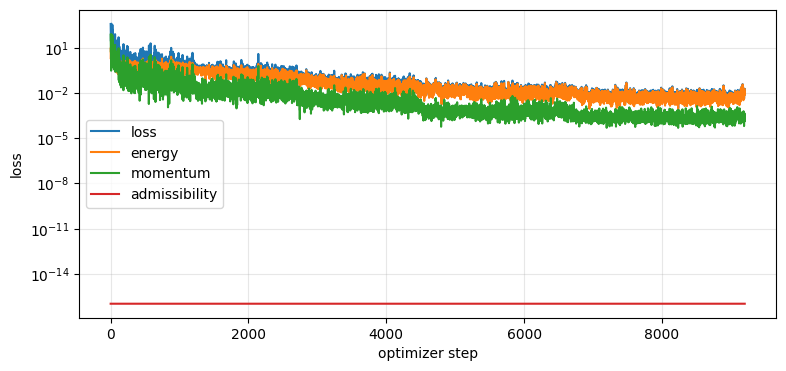

In [52]:
def plot_training_history(history):
    fig, ax = plt.subplots(figsize=(9, 4))
    for key in ["loss", "energy", "momentum", "admissibility"]:
        ax.semilogy(history["step"], np.maximum(history[key], 1e-16), label=key)
    ax.set_xlabel("optimizer step")
    ax.set_ylabel("loss")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.show()


plot_training_history(history_rnn)


### Продолжение полного обучения

После smoke test выполните следующую ячейку. Она продолжает обучение текущих весов, а не создаёт модель заново.


In [53]:
RUN_FULL_TRAINING = False

if RUN_FULL_TRAINING:
    full_curriculum = [
        (1, 1200, 8e-4),
        (4, 1500, 5e-4),
        (8, 1800, 3e-4),
        (16, 2200, 2e-4),
        (32, 2500, 1e-4),
        (64, 1800, 7e-5),
    ]
    history_full = train_physics_model(
        model=model_rnn,
        discrete=discrete,
        cfg=cfg,
        case=case,
        q_min=q_min,
        q_max=q_max,
        stages=full_curriculum,
        device=device,
    )
    history_rnn = pd.concat([history_rnn, history_full], ignore_index=True)
    plot_training_history(history_rnn)


## 5. Длинный causal rollout на реальном forcing

Для возбуждения неустойчивой моды к холодному начальному профилю добавляется малое гладкое возмущение. Это не target data. Excel-потоки рисуются только после rollout.


In [54]:
def forcing_q_arrays(case, forcing):
    t_star = forcing.tau * case.w0 / case.L
    q = (
        case.beta_pc / case.Cp_pc
        * forcing.power
        / (case.rho_pc * case.w0 * case.A)
    )
    return np.asarray(t_star), np.asarray(q)


@torch.no_grad()
def recurrent_rollout(
    model,
    discrete,
    cfg,
    case,
    forcing,
    dt=None,
    perturbation=1e-3,
    record_every=10,
    n_snapshots=60,
    max_steps=None,
):
    model.eval()
    dt = cfg.dt if dt is None else float(dt)
    device = next(model.parameters()).device
    dtype = next(model.parameters()).dtype

    t_forcing, q_forcing = forcing_q_arrays(case, forcing)
    n_steps = int(case.t_end_star / dt) if max_steps is None else int(max_steps)
    snap_every = max(1, n_steps // n_snapshots)

    z = discrete.z.to(device=device, dtype=dtype).reshape(1, -1)
    h = torch.full((1, cfg.n_cells), -case.nspc, device=device, dtype=dtype)
    h = h + perturbation * torch.sin(math.pi * z)
    Gin = torch.full((1, 1), case.G0_star * (1.0 + perturbation), device=device, dtype=dtype)
    IG = Gin.clone()
    hidden = None

    rec = {k: [] for k in ["t_star", "Gin", "Gout", "energy_rms", "momentum_abs", "h_min", "h_max"]}
    hsnap, tsnap = [], []

    for n in range(n_steps):
        t_star = n * dt
        q_value = float(np.interp(t_star, t_forcing, q_forcing))
        q = torch.full((1, 1), q_value, device=device, dtype=dtype)

        rho = discrete.thermo.rho(h)
        pred = model(h, rho, Gin, IG, q, dt, hidden)
        terms = discrete.residuals(h, pred["h_next"], pred["Gin_next"], IG, q, dt)

        h = pred["h_next"]
        Gin = pred["Gin_next"]
        IG = terms["IG1"]
        hidden = pred["hidden"]

        if n % record_every == 0:
            rec["t_star"].append(t_star)
            rec["Gin"].append(float(Gin.item()))
            rec["Gout"].append(float(terms["Gout"].item()))
            rec["energy_rms"].append(float(torch.sqrt(terms["R_energy"].square().mean()).item()))
            rec["momentum_abs"].append(float(terms["R_momentum"].abs().mean().item()))
            rec["h_min"].append(float(h.min().item()))
            rec["h_max"].append(float(h.max().item()))

        if n % snap_every == 0:
            hsnap.append(h.squeeze(0).cpu().numpy().copy())
            tsnap.append(t_star)

        if not torch.isfinite(h).all() or not torch.isfinite(Gin).all():
            print("Rollout stopped: non-finite state at step", n)
            break
        if h.abs().max() > 50.0 or Gin.abs().max() > 25.0:
            print("Rollout stopped: state left the trusted envelope at step", n)
            break

    out = {k: np.asarray(v) for k, v in rec.items()}
    out["t_sec"] = out["t_star"] * case.L / case.w0
    out["Gin_kgs"] = out["Gin"] * case.mdot0 / case.G0_star
    out["Gout_kgs"] = out["Gout"] * case.mdot0 / case.G0_star
    out["hsnap"] = np.asarray(hsnap)
    out["tsnap_sec"] = np.asarray(tsnap) * case.L / case.w0
    return out


# На smoke-весах сначала разумно проверить первые 1000 шагов.
# После full training установите max_steps=None для всей траектории.
rollout_steps = 1000 if FAST_DEV_RUN and not RUN_FULL_TRAINING else None
out_rnn = recurrent_rollout(
    model_rnn,
    discrete,
    cfg,
    case,
    forcing,
    perturbation=1e-3,
    record_every=5,
    max_steps=rollout_steps,
)

print(
    "records=", len(out_rnn["t_sec"]),
    "Gin kg/s range=", (out_rnn["Gin_kgs"].min(), out_rnn["Gin_kgs"].max()),
    "mean E residual=", out_rnn["energy_rms"].mean(),
    "mean M residual=", out_rnn["momentum_abs"].mean(),
)


Rollout stopped: state left the trusted envelope at step 11327
records= 2266 Gin kg/s range= (np.float64(-0.10114263870084866), np.float64(0.09014466887003986)) mean E residual= 29.92282287387337 mean M residual= 2.7526881864567674


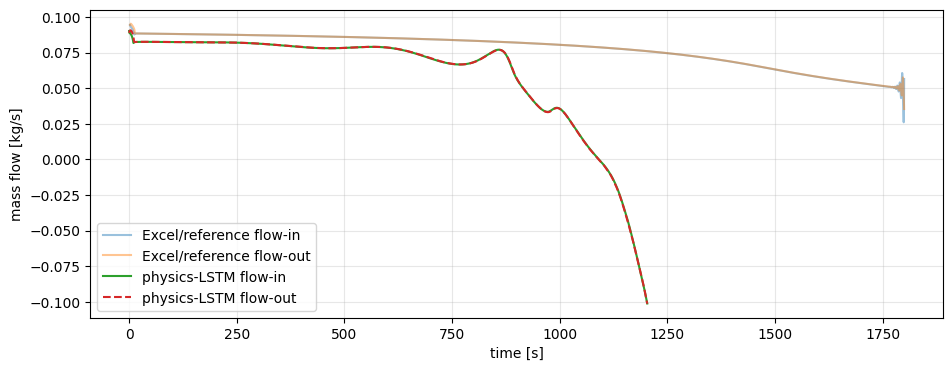

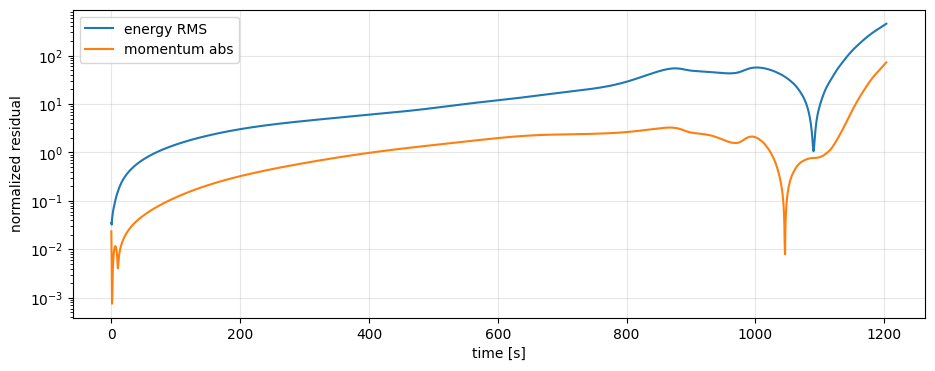

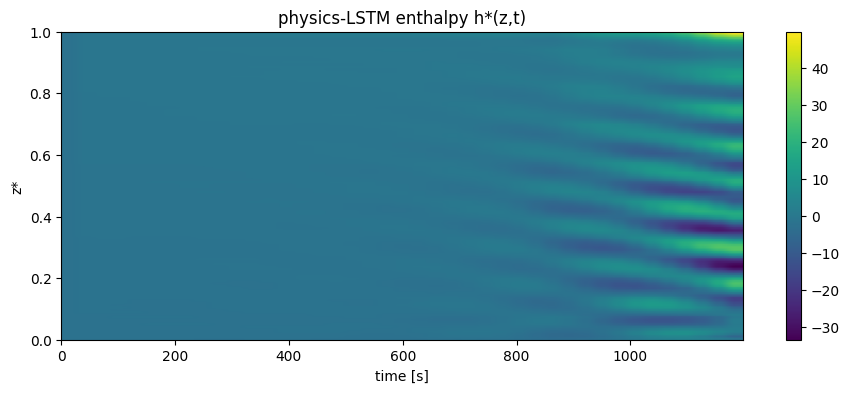

In [55]:
def plot_rollout(out_rnn, forcing, case):
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(forcing.time, forcing.flow_in, alpha=0.45, label="Excel/reference flow-in")
    ax.plot(forcing.time, forcing.flow_out, alpha=0.45, label="Excel/reference flow-out")
    ax.plot(out_rnn["t_sec"], out_rnn["Gin_kgs"], label="physics-LSTM flow-in")
    ax.plot(out_rnn["t_sec"], out_rnn["Gout_kgs"], linestyle="--", label="physics-LSTM flow-out")
    ax.set_xlabel("time [s]")
    ax.set_ylabel("mass flow [kg/s]")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.show()

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.semilogy(out_rnn["t_sec"], np.maximum(out_rnn["energy_rms"], 1e-12), label="energy RMS")
    ax.semilogy(out_rnn["t_sec"], np.maximum(out_rnn["momentum_abs"], 1e-12), label="momentum abs")
    ax.set_xlabel("time [s]")
    ax.set_ylabel("normalized residual")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.show()

    if out_rnn["hsnap"].size:
        fig, ax = plt.subplots(figsize=(11, 4))
        im = ax.imshow(
            out_rnn["hsnap"].T,
            aspect="auto",
            origin="lower",
            extent=[out_rnn["tsnap_sec"][0], out_rnn["tsnap_sec"][-1], 0.0, 1.0],
        )
        ax.set_xlabel("time [s]")
        ax.set_ylabel("z*")
        ax.set_title("physics-LSTM enthalpy h*(z,t)")
        fig.colorbar(im, ax=ax)
        plt.show()


plot_rollout(out_rnn, forcing, case)


## 6. Checkpoint


In [56]:
checkpoint_path = Path("physics_lstm_fv_dwo.pt")

torch.save(
    {
        "model_state": model_rnn.state_dict(),
        "config": cfg.__dict__,
        "history": history_rnn.to_dict(orient="list"),
    },
    checkpoint_path,
)
print("saved:", checkpoint_path.resolve())

# Load example:
# payload = torch.load(checkpoint_path, map_location=device)
# model_rnn.load_state_dict(payload["model_state"])


saved: /home/suchotin/pinn/Supercritical_stability_PINN/physics_lstm_fv_dwo.pt


## 7. Опциональный FV baseline

Следующая реализация не участвует в loss. В отличие от исходного варианта ошибка root solve не игнорируется молча.


In [57]:
import numpy as np
from scipy.optimize import brentq


class FVSolver:
    """Semi-implicit upwind method-of-lines solver for the supercritical DWO model.

    Unconditionally-stable in the advection (implicit upwind) so dt is not CFL-bound,
    and the inlet-flow inertia is integrated with backward-Euler so the flow<->dp
    feedback cannot blow up. Both the implicit enthalpy sweep and the continuity
    reconstruction of G(z) are the SAME linear recurrence G_j = a_j G_{j-1} + b_j,
    solved vectorized via cumprod/cumsum (no Python cell loop).
    """

    def __init__(self, physics, case, N=600):
        self.ph = physics
        self.case = case
        self.N = N
        self.dz = 1.0 / N
        self.h_in = -case.nspc                     # inlet enthalpy BC (h*/nspc + 1 = 0)
        rho_in, _ = physics.eos25(torch.tensor([self.h_in]))
        self.rho_in = float(rho_in.reshape(()))

    @staticmethod
    def _affine_scan(a, b, h0):
        """h_j = a_j h_{j-1} + b_j with h_0 = h0, WITHOUT the cumprod/division
        trick (which underflows to 0/0 when the flow stagnates, a_j -> 0, and
        breaks on locally reversed flow, a_j < 0). Hillis-Steele parallel prefix
        over affine maps: compose (A2,B2)o(A1,B1) = (A2*A1, A2*B1 + B2) in
        O(log N) vector ops -- no division, unconditionally stable numerics."""
        A = a.clone()
        B = b.clone()
        offset = 1
        N = a.shape[0]
        while offset < N:
            A_prev = torch.ones_like(A)
            B_prev = torch.zeros_like(B)
            A_prev[offset:] = A[:-offset]
            B_prev[offset:] = B[:-offset]
            B = A * B_prev + B
            A = A * A_prev
            offset *= 2
        return A * h0 + B

    def _dp_consumed(self, Gin, G_S, rho, rho_out, h):
        # G(z) = Gin - G_S(z) from continuity; integrated momentum sink (imposed-dp balance)
        ph, case, dz = self.ph, self.case, self.dz
        G = Gin - G_S
        G_out = float(G[-1])
        flux = G_out ** 2 / rho_out - Gin ** 2 / self.rho_in
        gravity = float(torch.sum(rho / case.Fr) * dz)
        Ld, slf, _, _ = ph.distributed_friction(G=G, h=h, rho=rho)
        friction = float(torch.sum(Ld * slf) * dz)
        local_in = 0.5 * case.kin * Gin * abs(Gin) / self.rho_in
        local_out = 0.5 * case.kout * G_out * abs(G_out) / rho_out
        return flux + gravity + friction + local_in + local_out

    @torch.no_grad()
    def run(self, T=None, dt=0.05, inertia=None, n_rec=1500, n_snap=13):
        # inertia=None (default): EXACT integral momentum d/dt int G dz = dpi - dp,
        #   with int G dz = G_in - I_S reconstructed from continuity each step --
        #   the distributed-storage term dI_S/dt ('channel breathing') included,
        #   no free knob. inertia=<float>: legacy lumped model
        #   Lambda dG_in/dt = dpi - dp (drops the storage term; Lambda arbitrary).
        case, dz, N = self.case, self.dz, self.N
        T = case.t_end_star if T is None else T
        nstep = int(T / dt)
        h = torch.full((N,), self.h_in)
        Gin = case.G0_star
        Gprof = torch.full((N,), Gin)              # lagged G-profile for the advection coeff
        IG_prev = Gin                              # int_0^1 G dz of the previous step (uniform IC)
        rec = {k: [] for k in ("t", "Gin", "Gout")}
        snaps, snap_t = [], []

        for n in range(nstep):
            t = n * dt
            rho, _ = self.ph.eos25(h); rho = rho.float()
            NQ = float(self.ph.NQ_prime(torch.tensor([t])).reshape(()))

            # --- implicit upwind enthalpy update (unconditionally stable) --------
            # h_new_j (1 + c_j) = (h_j + dt NQ/rho_j) + c_j h_new_{j-1},  c_j = dt G_j/(rho_j dz)
            # upwind assumes flow >= 0; clamp locally-reversed cells to stagnant
            # transport (severe-DWO reversal would need bidirectional upwind)
            c = dt * torch.clamp(Gprof, min=0.0) / (rho * dz)
            a = c / (1.0 + c)
            b = (h + dt * NQ / rho) / (1.0 + c)
            h_new = self._affine_scan(a, b, self.h_in)
            dhdt = (h_new - h) / dt
            h = h_new

            # --- continuity: G(z) = Gin - dz * cumsum(chi dh/dt) -----------------
            rho, chi = self.ph.eos25(h); rho = rho.float(); chi = chi.float()
            rho_out = float(rho[-1])
            G_S = dz * torch.cumsum(chi * dhdt, 0)

            # --- integral momentum, backward-Euler (stable any dt) ---------------
            # exact: (int G dz)^{n+1} - (int G dz)^n = dt (dpi - dp_consumed),
            # with (int G dz)^{n+1} = g - I_S  (I_S known from the enthalpy step,
            # independent of g) -> scalar root problem in g = G_in^{n+1}.
            I_S = float(torch.sum(G_S)) * dz
            if inertia is None:
                f = lambda g: (g - I_S - IG_prev) - dt * (
                    case.dpi_star - self._dp_consumed(g, G_S, rho, rho_out, h))
            else:                                   # legacy lumped Lambda-model
                f = lambda g: (g - Gin) - (dt / inertia) * (
                    case.dpi_star - self._dp_consumed(g, G_S, rho, rho_out, h))
            try:
                # bracket reaches below 0: deep DWO excursions hit stagnation and
                # the old floor 0.02 silently CLIPPED the root (measured: min G_in
                # sat exactly at the bracket edge). Reversed inflow is handled by
                # the advection clamp (transport treated as stagnant).
                Gin = brentq(f, -3.0, 15.0, xtol=1e-5, rtol=1e-5, maxiter=60)
            except Exception as exc:
                raise RuntimeError(f"Momentum root solve failed at step {n}, t*={t:.6g}") from exc
            Gprof = Gin - G_S
            IG_prev = Gin - I_S

            if n % max(1, nstep // n_rec) == 0:
                rec["t"].append(t); rec["Gin"].append(Gin); rec["Gout"].append(float(Gprof[-1]))
            if n % max(1, nstep // n_snap) == 0:
                snaps.append(h.numpy().copy()); snap_t.append(t)

        out = {k: np.asarray(v) for k, v in rec.items()}
        out["hsnap"] = np.asarray(snaps)
        out["tsnap"] = np.asarray(snap_t)
        # dimensional mass flow [kg/s] and physical time [s]
        out["Gin_kgs"] = out["Gin"] * case.mdot0 / case.G0_star
        out["Gout_kgs"] = out["Gout"] * case.mdot0 / case.G0_star
        out["t_sec"] = out["t"] * case.L / case.w0
        return out

In [58]:
RUN_FV_BASELINE = False

if RUN_FV_BASELINE:
    solver = FVSolver(physics, case, N=600)
    out_fv = solver.run(T=case.t_end_star, dt=0.05)

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(out_fv["t_sec"], out_fv["Gin_kgs"], label="FV flow-in")
    ax.plot(out_fv["t_sec"], out_fv["Gout_kgs"], linestyle="--", label="FV flow-out")
    ax.plot(out_rnn["t_sec"], out_rnn["Gin_kgs"], label="physics-LSTM flow-in")
    ax.plot(out_rnn["t_sec"], out_rnn["Gout_kgs"], linestyle="--", label="physics-LSTM flow-out")
    ax.set_xlabel("time [s]")
    ax.set_ylabel("mass flow [kg/s]")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.show()


## Интерпретация результата

Критерии успешного эксперимента:

- hard mass residual остаётся на уровне машинной точности;
- normalized energy и momentum residual уменьшаются как на обучающих rollout, так и на длинной траектории;
- при малом возмущении появляется воспроизводимый onset DWO, а его период и growth rate сходятся при изменении `n_cells` и `dt`;
- амплитуда не должна оцениваться до grid/time-step convergence и до устранения выхода EOS за доверенный диапазон.

Если сеть снова даёт только гладкую ветвь, сначала увеличьте rollout curriculum до 64–128, затем добавьте в `sample_smooth_states` профили около dominant unstable mode из линеаризованного FV solver. Не подмешивайте FV trajectory в loss, если требуется сохранить полностью physics-only постановку.
